In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ============================================================
# LOAD DATA
# ============================================================
#df = pd.read_csv("targeted_sdp_synthetic_partial.csv")
#df = pd.read_csv("final_results_synthetics.csv")
df = pd.read_csv("complete.csv")

In [14]:
# 10 ten biggest errors cases


619    0.107967
621    0.090436
608    0.073016
606    0.042238
716    0.038457
620    0.027905
601    0.027458
719    0.025835
715    0.024490
108    0.022418
Name: PT_Absolute_Error, dtype: float64

In [2]:
df.head()

,Network,N_Nodes,Density,Rigidity,Hidden_Ratio,Target_Bucket,Target_Node,Target_Value,Number_Subnetworks,Max_Partition_Size,...,MCMC_Avg_Time_sec,MCMC_Peak_Memory_MB_Python,MCMC_Peak_Memory_MB_RSS,Absolute_Error,PT_MCMC_Mean_SDP,PT_MCMC_Variance,PT_MCMC_Avg_Time_sec,PT_Peak_Memory_MB_Python,PT_Peak_Memory_MB_RSS,PT_Absolute_Error
0,bn_n100_w2_concentrated_bias_high.bif,100,2,concentrated_bias_high,0.25,0.5,X4,1,15,4,...,1.059610,0.172319,0.0,0.003970,0.4738,0.000297,4.359977,0.301787,0.0,0.000330
1,bn_n100_w2_concentrated_bias_high.bif,100,2,concentrated_bias_high,0.25,0.8,X4,1,17,3,...,0.951802,0.166064,0.0,0.004066,0.8170,0.000050,3.855537,0.274520,0.0,0.000766
2,bn_n100_w2_concentrated_bias_high.bif,100,2,concentrated_bias_high,0.25,0.9,X4,1,15,4,...,1.006047,0.170017,0.0,0.001552,0.9550,0.000056,4.173990,0.284065,0.0,0.005452
3,bn_n100_w2_concentrated_bias_high.bif,100,2,concentrated_bias_high,0.25,1.0,X4,1,18,5,...,0.972042,0.167065,0.0,0.000000,1.0000,0.000000,3.976135,0.280487,0.0,0.000000
4,bn_n100_w2_concentrated_bias_high.bif,100,2,concentrated_bias_high,0.50,0.5,X4,1,15,12,...,1.001391,0.178783,0.0,0.006745,0.4584,0.000132,4.079318,0.295380,0.0,0.001445


In [3]:
done_nets = df.Network.unique()

In [4]:
for net in done_nets:
    print(net)

bn_n100_w2_concentrated_bias_high.bif
bn_n100_w2_concentrated_bias_low.bif
bn_n100_w2_rigid_extreme.bif
bn_n100_w2_rigid_moderate.bif
bn_n100_w2_spread_bias_high.bif
bn_n100_w2_spread_bias_low.bif
bn_n100_w2_uncertain_moderate.bif
bn_n100_w2_uncertain_strong.bif
bn_n100_w2_uniform.bif
bn_n100_w6_concentrated_bias_high.bif
bn_n100_w6_concentrated_bias_low.bif
bn_n100_w6_rigid_extreme.bif
bn_n100_w6_rigid_moderate.bif
bn_n100_w6_spread_bias_high.bif
bn_n100_w6_spread_bias_low.bif
bn_n100_w6_uncertain_moderate.bif
bn_n100_w6_uncertain_strong.bif
bn_n100_w6_uniform.bif
bn_n20_w2_concentrated_bias_high.bif
bn_n20_w2_concentrated_bias_low.bif
bn_n20_w2_rigid_extreme.bif
bn_n20_w2_rigid_moderate.bif
bn_n20_w2_spread_bias_high.bif
bn_n20_w2_spread_bias_low.bif
bn_n20_w2_uncertain_moderate.bif
bn_n20_w2_uncertain_strong.bif
bn_n20_w2_uniform.bif
bn_n20_w6_concentrated_bias_high.bif
bn_n20_w6_concentrated_bias_low.bif
bn_n20_w6_rigid_extreme.bif
bn_n20_w6_rigid_moderate.bif
bn_n20_w6_spread_bias

=== Cell counts (Density × Rigidity) ===
Rigidity     uniform  spread_bias_low  spread_bias_high  \
Density_Cat                                               
Sparse            56               51                54   
Dense             40               36                41   

Rigidity     concentrated_bias_low  concentrated_bias_high  \
Density_Cat                                                  
Sparse                          40                      50   
Dense                           23                      53   

Rigidity     uncertain_moderate  uncertain_strong  rigid_moderate  \
Density_Cat                                                         
Sparse                       46                50              54   
Dense                        39                35              39   

Rigidity     rigid_extreme  
Density_Cat                 
Sparse                  53  
Dense                   38  



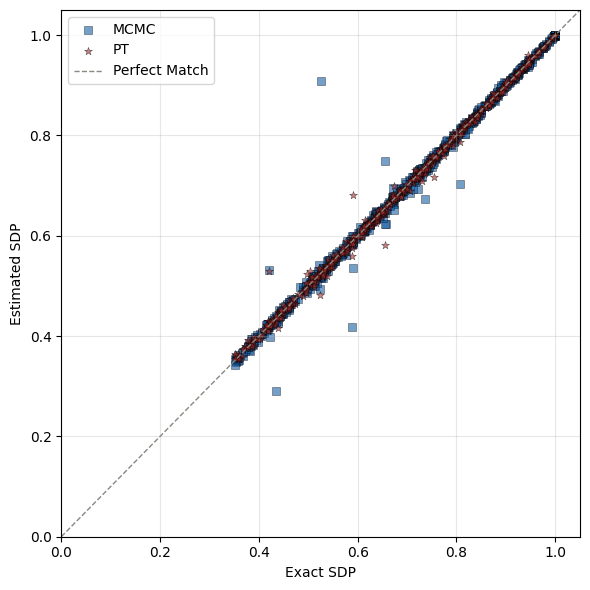

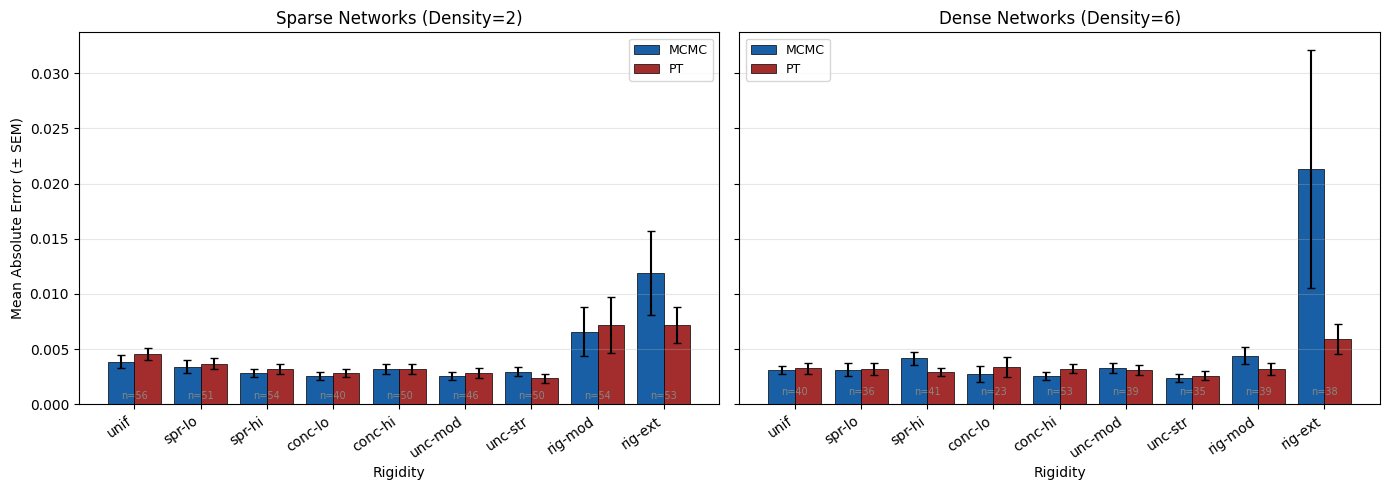

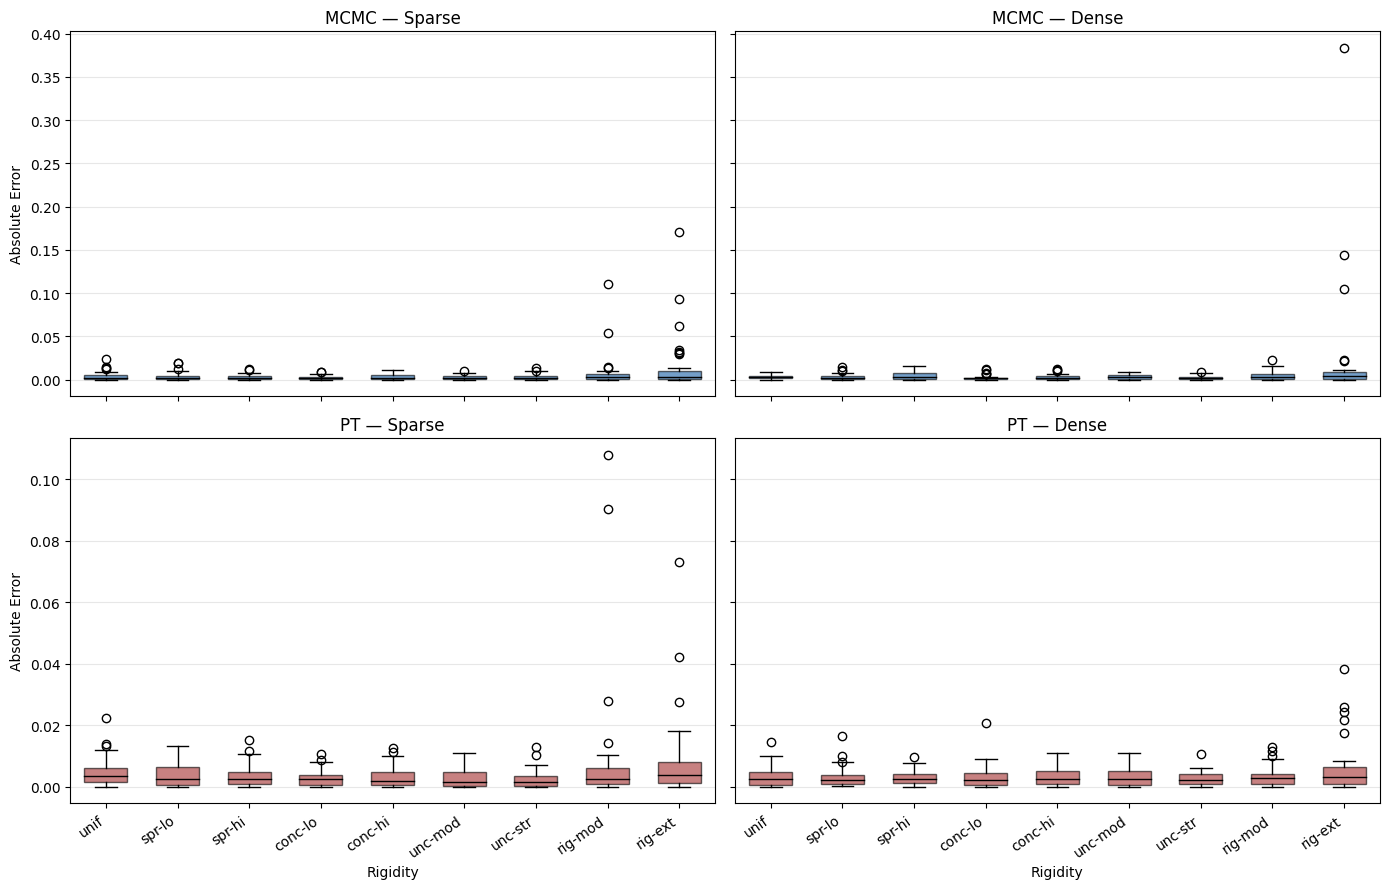

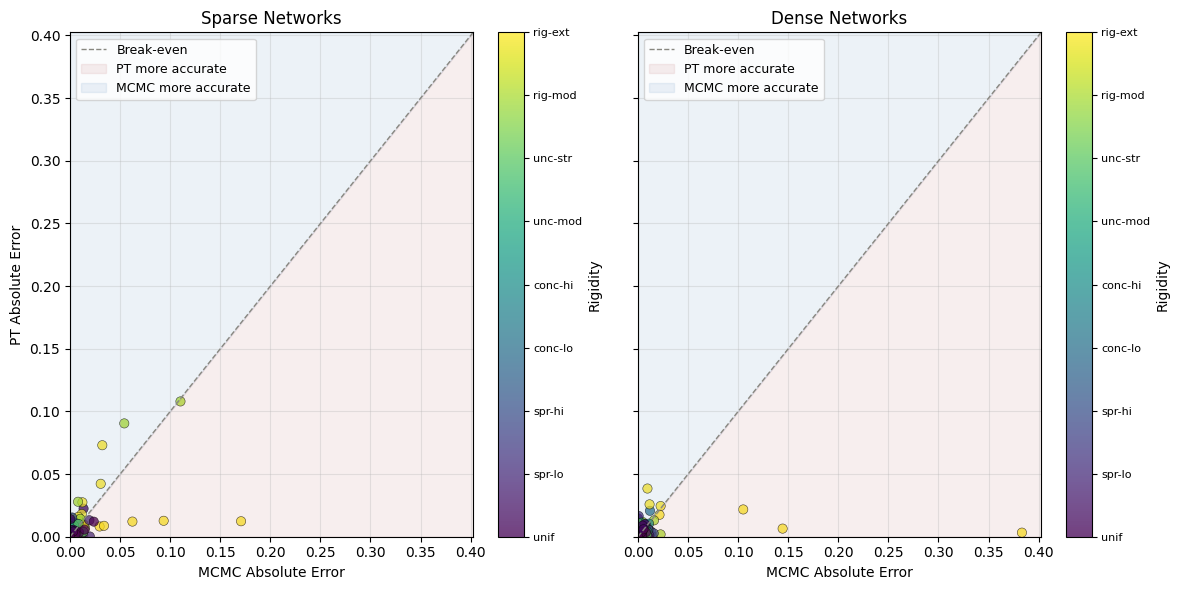

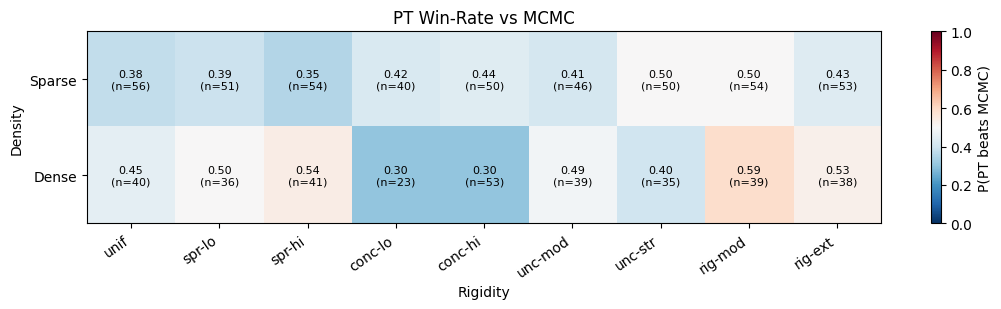

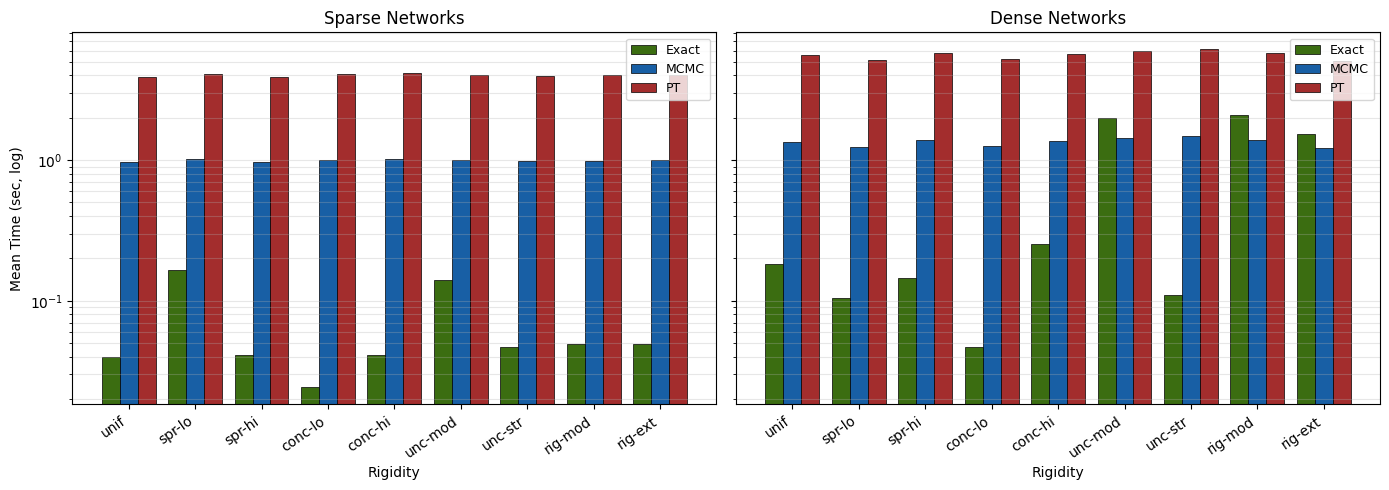


=== Summary by Density × Rigidity ===
                                     n  MCMC_mean_err  MCMC_std_err  \
Density_Cat Rigidity                                                  
Sparse      uniform                 56         0.0039        0.0044   
            spread_bias_low         51         0.0034        0.0042   
            spread_bias_high        54         0.0028        0.0028   
            concentrated_bias_low   40         0.0025        0.0023   
            concentrated_bias_high  50         0.0032        0.0030   
            uncertain_moderate      46         0.0026        0.0025   
            uncertain_strong        50         0.0030        0.0030   
            rigid_moderate          54         0.0066        0.0163   
            rigid_extreme           53         0.0119        0.0276   
Dense       uniform                 40         0.0031        0.0023   
            spread_bias_low         36         0.0031        0.0034   
            spread_bias_high        41

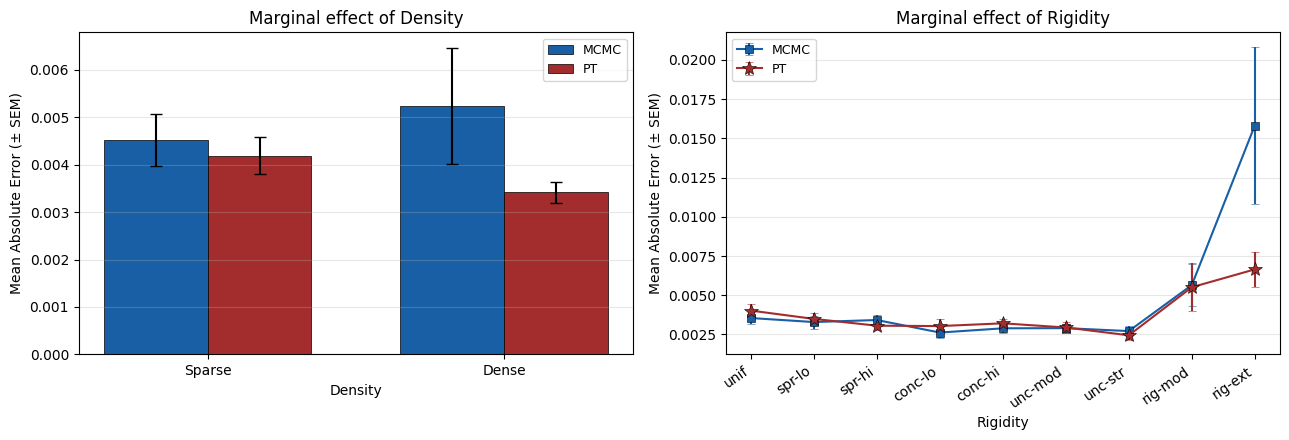

In [5]:

# ============================================================
# COLORS
# ============================================================
BLUE   = '#185FA5'
RED    = '#A32D2D'
AMBER  = '#B85C00'
GREEN  = '#3B6D11'
GRAY   = '#888780'

METHOD_COLORS  = {'Exact': GREEN, 'MCMC': BLUE, 'PT': RED}
METHOD_MARKERS = {'Exact': 'o',   'MCMC': 's',  'PT': '*'}

# ============================================================
# CATEGORICAL ENCODING
# ============================================================
# Density: 2 = sparse, 6 = dense
df['Density_Cat'] = df['Density'].map({2: 'Sparse', 6: 'Dense'})

# Rigidity: 9 ordered levels, from least to most "opinionated"
RIGIDITY_ORDER = [
    'uniform',
    'spread_bias_low',
    'spread_bias_high',
    'concentrated_bias_low',
    'concentrated_bias_high',
    'uncertain_moderate',
    'uncertain_strong',
    'rigid_moderate',
    'rigid_extreme',
]
# Short labels for axis ticks (the full names are too long for x-ticks)
RIGIDITY_SHORT = {
    'uniform':                'unif',
    'spread_bias_low':        'spr-lo',
    'spread_bias_high':       'spr-hi',
    'concentrated_bias_low':  'conc-lo',
    'concentrated_bias_high': 'conc-hi',
    'uncertain_moderate':     'unc-mod',
    'uncertain_strong':       'unc-str',
    'rigid_moderate':         'rig-mod',
    'rigid_extreme':          'rig-ext',
}
df['Rigidity'] = pd.Categorical(df['Rigidity'],
                                 categories=RIGIDITY_ORDER, ordered=True)
df['Density_Cat'] = pd.Categorical(df['Density_Cat'],
                                    categories=['Sparse', 'Dense'], ordered=True)

print("=== Cell counts (Density × Rigidity) ===")
print(pd.crosstab(df['Density_Cat'], df['Rigidity']))
print()

# Convenience
short_labels = [RIGIDITY_SHORT[r] for r in RIGIDITY_ORDER]
x_pos = np.arange(len(RIGIDITY_ORDER))

# ============================================================
# 1. SANITY CHECK — Exact vs Estimated SDP
# ============================================================
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(df['Exact_SDP'], df['MCMC_Mean_SDP'],
           color=METHOD_COLORS['MCMC'], alpha=0.6, s=35,
           marker=METHOD_MARKERS['MCMC'], label='MCMC',
           edgecolors='black', linewidths=0.4)
ax.scatter(df['Exact_SDP'], df['PT_MCMC_Mean_SDP'],
           color=METHOD_COLORS['PT'], alpha=0.6, s=35,
           marker=METHOD_MARKERS['PT'], label='PT',
           edgecolors='black', linewidths=0.4)
lims = [0, 1.05]
ax.plot(lims, lims, color=GRAY, ls='--', lw=1, label='Perfect Match')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Exact SDP'); ax.set_ylabel('Estimated SDP')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_1_exact_vs_estimated.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 2. MEAN ABSOLUTE ERROR BY RIGIDITY × DENSITY (grouped bars)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, dens in zip(axes, ['Sparse', 'Dense']):
    sub = df[df['Density_Cat'] == dens]
    g = sub.groupby('Rigidity', observed=True).agg(
        mcmc_mean=('Absolute_Error',    'mean'),
        mcmc_sem =('Absolute_Error',    'sem'),
        pt_mean  =('PT_Absolute_Error', 'mean'),
        pt_sem   =('PT_Absolute_Error', 'sem'),
    ).reindex(RIGIDITY_ORDER)

    width = 0.4
    ax.bar(x_pos - width/2, g['mcmc_mean'], width, yerr=g['mcmc_sem'],
           capsize=3, color=METHOD_COLORS['MCMC'], label='MCMC',
           edgecolor='black', linewidth=0.5)
    ax.bar(x_pos + width/2, g['pt_mean'], width, yerr=g['pt_sem'],
           capsize=3, color=METHOD_COLORS['PT'], label='PT',
           edgecolor='black', linewidth=0.5)

    n_per_cell = sub.groupby('Rigidity', observed=True).size().reindex(RIGIDITY_ORDER, fill_value=0)
    for i, n in enumerate(n_per_cell):
        ax.text(i, ax.get_ylim()[1] * 0.02, f'n={n}', ha='center',
                va='bottom', fontsize=7, color=GRAY)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(short_labels, rotation=35, ha='right')
    ax.set_xlabel('Rigidity')
    ax.set_title(f'{dens} Networks (Density={2 if dens=="Sparse" else 6})')
    ax.grid(True, alpha=0.3, axis='y')
    if dens == 'Sparse':
        ax.set_ylabel('Mean Absolute Error (± SEM)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('plot_2_error_by_rigidity_density.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 3. ERROR DISTRIBUTION (boxplots) BY RIGIDITY × DENSITY
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey='row', sharex='col')

for col, dens in enumerate(['Sparse', 'Dense']):
    sub = df[df['Density_Cat'] == dens]

    # Build per-cell data, marking empty cells so positions stay aligned
    mcmc_data, pt_data, mcmc_pos, pt_pos = [], [], [], []
    for i, r in enumerate(RIGIDITY_ORDER):
        cell = sub[sub['Rigidity'] == r]
        if len(cell) > 0:
            mcmc_data.append(cell['Absolute_Error'].values)
            pt_data.append(cell['PT_Absolute_Error'].values)
            mcmc_pos.append(i)
            pt_pos.append(i)

    # MCMC
    if mcmc_data:
        bp = axes[0, col].boxplot(mcmc_data, positions=mcmc_pos, widths=0.6,
                                   patch_artist=True,
                                   medianprops=dict(color='black'))
        for p in bp['boxes']:
            p.set_facecolor(METHOD_COLORS['MCMC']); p.set_alpha(0.6)
    axes[0, col].set_title(f'MCMC — {dens}')
    axes[0, col].set_xlim(-0.5, len(RIGIDITY_ORDER) - 0.5)
    axes[0, col].grid(True, alpha=0.3, axis='y')

    # PT
    if pt_data:
        bp = axes[1, col].boxplot(pt_data, positions=pt_pos, widths=0.6,
                                   patch_artist=True,
                                   medianprops=dict(color='black'))
        for p in bp['boxes']:
            p.set_facecolor(METHOD_COLORS['PT']); p.set_alpha(0.6)
    axes[1, col].set_title(f'PT — {dens}')
    axes[1, col].set_xticks(x_pos)
    axes[1, col].set_xticklabels(short_labels, rotation=35, ha='right')
    axes[1, col].set_xlabel('Rigidity')
    axes[1, col].set_xlim(-0.5, len(RIGIDITY_ORDER) - 0.5)
    axes[1, col].grid(True, alpha=0.3, axis='y')

axes[0, 0].set_ylabel('Absolute Error')
axes[1, 0].set_ylabel('Absolute Error')
plt.tight_layout()
plt.savefig('plot_3_error_distribution_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 4. PT vs MCMC HEAD-TO-HEAD — split by density
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

max_err = max(df['Absolute_Error'].max(), df['PT_Absolute_Error'].max())
lims2 = [0, max_err * 1.05]

# Use integer codes for the rigidity colorbar
rig_codes = df['Rigidity'].cat.codes

for ax, dens in zip(axes, ['Sparse', 'Dense']):
    sub = df[df['Density_Cat'] == dens]
    sc = ax.scatter(sub['Absolute_Error'], sub['PT_Absolute_Error'],
                    c=sub['Rigidity'].cat.codes, cmap='viridis',
                    vmin=0, vmax=len(RIGIDITY_ORDER) - 1,
                    alpha=0.75, s=45, edgecolors='black', linewidths=0.4)

    ax.plot(lims2, lims2, color=GRAY, ls='--', lw=1, label='Break-even')
    ax.fill_between(lims2, 0, lims2, color=METHOD_COLORS['PT'],   alpha=0.08,
                    label='PT more accurate')
    ax.fill_between(lims2, lims2, [lims2[1]] * 2, color=METHOD_COLORS['MCMC'],
                    alpha=0.08, label='MCMC more accurate')

    ax.set_xlim(lims2); ax.set_ylim(lims2)
    ax.set_xlabel('MCMC Absolute Error')
    ax.set_title(f'{dens} Networks')
    ax.grid(True, alpha=0.3); ax.legend(loc='upper left', fontsize=9)
    cbar = plt.colorbar(sc, ax=ax, ticks=x_pos)
    cbar.ax.set_yticklabels(short_labels, fontsize=8)
    cbar.set_label('Rigidity')

axes[0].set_ylabel('PT Absolute Error')
plt.tight_layout()
plt.savefig('plot_4_head_to_head_by_density.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 5. WIN-RATE HEATMAP — where does PT beat MCMC?
# ============================================================
df['PT_Wins'] = (df['PT_Absolute_Error'] < df['Absolute_Error']).astype(int)

win_table = df.groupby(['Density_Cat', 'Rigidity'], observed=True)['PT_Wins'] \
              .mean().unstack().reindex(columns=RIGIDITY_ORDER) \
              .reindex(['Sparse', 'Dense'])
n_table = df.groupby(['Density_Cat', 'Rigidity'], observed=True).size() \
             .unstack(fill_value=0).reindex(columns=RIGIDITY_ORDER) \
             .reindex(['Sparse', 'Dense'])

fig, ax = plt.subplots(figsize=(11, 3.2))
im = ax.imshow(win_table.values, cmap='RdBu_r', vmin=0, vmax=1, aspect='auto')

ax.set_xticks(x_pos); ax.set_xticklabels(short_labels, rotation=35, ha='right')
ax.set_yticks(range(len(win_table.index)))
ax.set_yticklabels(win_table.index)
ax.set_xlabel('Rigidity'); ax.set_ylabel('Density')

for i in range(win_table.shape[0]):
    for j in range(win_table.shape[1]):
        v = win_table.values[i, j]
        n = n_table.values[i, j]
        if pd.isna(v):
            ax.text(j, i, '—', ha='center', va='center', color='black', fontsize=10)
        else:
            color = 'white' if abs(v - 0.5) > 0.25 else 'black'
            ax.text(j, i, f'{v:.2f}\n(n={n})', ha='center', va='center',
                    color=color, fontsize=8)

cbar = plt.colorbar(im, ax=ax); cbar.set_label('P(PT beats MCMC)')
ax.set_title('PT Win-Rate vs MCMC')
plt.tight_layout()
plt.savefig('plot_5_pt_winrate.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 6. EXECUTION TIME BY RIGIDITY × DENSITY (log scale)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, dens in zip(axes, ['Sparse', 'Dense']):
    sub = df[df['Density_Cat'] == dens]
    g = sub.groupby('Rigidity', observed=True).agg(
        exact=('Exact_Time_sec',       'mean'),
        mcmc =('MCMC_Avg_Time_sec',    'mean'),
        pt   =('PT_MCMC_Avg_Time_sec', 'mean'),
    ).reindex(RIGIDITY_ORDER)

    width = 0.27
    ax.bar(x_pos - width, g['exact'], width, color=METHOD_COLORS['Exact'],
           label='Exact', edgecolor='black', linewidth=0.5)
    ax.bar(x_pos,         g['mcmc'],  width, color=METHOD_COLORS['MCMC'],
           label='MCMC',  edgecolor='black', linewidth=0.5)
    ax.bar(x_pos + width, g['pt'],    width, color=METHOD_COLORS['PT'],
           label='PT',    edgecolor='black', linewidth=0.5)

    ax.set_yscale('log')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(short_labels, rotation=35, ha='right')
    ax.set_xlabel('Rigidity')
    ax.set_title(f'{dens} Networks')
    ax.grid(True, alpha=0.3, axis='y', which='both')
    if dens == 'Sparse':
        ax.set_ylabel('Mean Time (sec, log)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('plot_6_time_by_rigidity_density.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 7. SUMMARY TABLE
# ============================================================
summary = df.groupby(['Density_Cat', 'Rigidity'], observed=True).agg(
    n              =('Absolute_Error',       'size'),
    MCMC_mean_err  =('Absolute_Error',       'mean'),
    MCMC_std_err   =('Absolute_Error',       'std'),
    MCMC_max_err   =('Absolute_Error',       'max'),
    PT_mean_err    =('PT_Absolute_Error',    'mean'),
    PT_std_err     =('PT_Absolute_Error',    'std'),
    PT_max_err     =('PT_Absolute_Error',    'max'),
    PT_winrate     =('PT_Wins',              'mean'),
    Exact_mean_time=('Exact_Time_sec',       'mean'),
    MCMC_mean_time =('MCMC_Avg_Time_sec',    'mean'),
    PT_mean_time   =('PT_MCMC_Avg_Time_sec', 'mean'),
).round(4)

print("\n=== Summary by Density × Rigidity ===")
print(summary)
summary.to_csv('summary_density_rigidity.csv')

# ============================================================
# 8. MARGINAL EFFECTS — overall view of the two factors
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) Marginal effect of density
dens_summary = df.groupby('Density_Cat', observed=True).agg(
    mcmc_mean=('Absolute_Error',    'mean'),
    mcmc_sem =('Absolute_Error',    'sem'),
    pt_mean  =('PT_Absolute_Error', 'mean'),
    pt_sem   =('PT_Absolute_Error', 'sem'),
)
xd = np.arange(len(dens_summary)); width = 0.35
axes[0].bar(xd - width/2, dens_summary['mcmc_mean'], width,
            yerr=dens_summary['mcmc_sem'], capsize=4,
            color=METHOD_COLORS['MCMC'], label='MCMC',
            edgecolor='black', linewidth=0.5)
axes[0].bar(xd + width/2, dens_summary['pt_mean'], width,
            yerr=dens_summary['pt_sem'], capsize=4,
            color=METHOD_COLORS['PT'], label='PT',
            edgecolor='black', linewidth=0.5)
axes[0].set_xticks(xd); axes[0].set_xticklabels(dens_summary.index)
axes[0].set_xlabel('Density')
axes[0].set_ylabel('Mean Absolute Error (± SEM)')
axes[0].set_title('Marginal effect of Density')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3, axis='y')

# (b) Marginal effect of rigidity
rig_summary = df.groupby('Rigidity', observed=True).agg(
    mcmc_mean=('Absolute_Error',    'mean'),
    mcmc_sem =('Absolute_Error',    'sem'),
    pt_mean  =('PT_Absolute_Error', 'mean'),
    pt_sem   =('PT_Absolute_Error', 'sem'),
).reindex(RIGIDITY_ORDER)

axes[1].errorbar(x_pos, rig_summary['mcmc_mean'], yerr=rig_summary['mcmc_sem'],
                 fmt='-s', color=METHOD_COLORS['MCMC'], label='MCMC',
                 capsize=3, lw=1.5, markeredgecolor='black', markeredgewidth=0.4)
axes[1].errorbar(x_pos, rig_summary['pt_mean'], yerr=rig_summary['pt_sem'],
                 fmt='-*', color=METHOD_COLORS['PT'], label='PT',
                 capsize=3, lw=1.5, markersize=10,
                 markeredgecolor='black', markeredgewidth=0.4)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(short_labels, rotation=35, ha='right')
axes[1].set_xlabel('Rigidity')
axes[1].set_ylabel('Mean Absolute Error (± SEM)')
axes[1].set_title('Marginal effect of Rigidity')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('plot_8_marginal_effects.png', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
df.columns

Index(['Network', 'N_Nodes', 'Density', 'Rigidity', 'Hidden_Ratio',
       'Target_Bucket', 'Target_Node', 'Target_Value', 'Number_Subnetworks',
       'Max_Partition_Size', 'Max_Tensor_Size', 'Threshold_Distance',
       'Exact_SDP', 'Exact_Time_sec', 'Exact_Peak_Memory_MB_Python',
       'Exact_Peak_Memory_MB_RSS', 'Exact_SDP_Original',
       'Exact_Time_sec_Original', 'Exact_Peak_Memory_MB_Python_Original',
       'Exact_Peak_Memory_MB_RSS_Original', 'Exact_SDP_Original_Status',
       'MCMC_Mean_SDP', 'MCMC_Variance', 'MCMC_Avg_Time_sec',
       'MCMC_Peak_Memory_MB_Python', 'MCMC_Peak_Memory_MB_RSS',
       'Absolute_Error', 'PT_MCMC_Mean_SDP', 'PT_MCMC_Variance',
       'PT_MCMC_Avg_Time_sec', 'PT_Peak_Memory_MB_Python',
       'PT_Peak_Memory_MB_RSS', 'PT_Absolute_Error', 'Density_Cat', 'PT_Wins'],
      dtype='object')

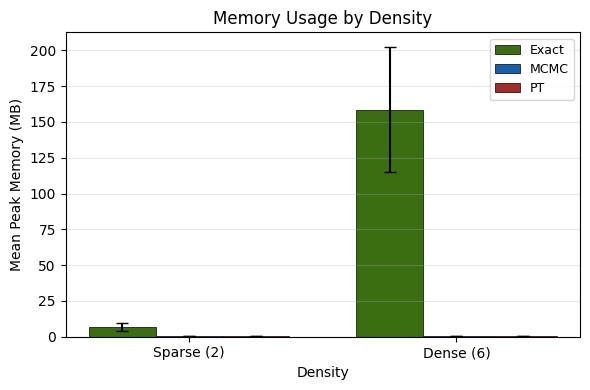

In [7]:
# how density affects memory usage (Exact_Peak_Memory_MB, MCMC_Peak_Memory_MB, PT_Peak_Memory_MB)
memory_summary = df.groupby('Density', observed=True).agg(
    exact_mem_mean=('Exact_Peak_Memory_MB_Python', 'mean'),
    exact_mem_sem =('Exact_Peak_Memory_MB_Python', 'sem'),
    mcmc_mem_mean =('MCMC_Peak_Memory_MB_Python', 'mean'),
    mcmc_mem_sem  =('MCMC_Peak_Memory_MB_Python', 'sem'),
    pt_mem_mean   =('PT_Peak_Memory_MB_Python', 'mean'),
    pt_mem_sem    =('PT_Peak_Memory_MB_Python', 'sem'),
)

# plot
fig, ax = plt.subplots(figsize=(6, 4))
xd = np.arange(len(memory_summary)); width = 0.25
ax.bar(xd - width, memory_summary['exact_mem_mean'], width,
       yerr=memory_summary['exact_mem_sem'], capsize=4,
       color=METHOD_COLORS['Exact'], label='Exact',
       edgecolor='black', linewidth=0.5)
ax.bar(xd, memory_summary['mcmc_mem_mean'], width,
       yerr=memory_summary['mcmc_mem_sem'], capsize=4,
       color=METHOD_COLORS['MCMC'], label='MCMC',
       edgecolor='black', linewidth=0.5)
ax.bar(xd + width, memory_summary['pt_mem_mean'], width,
       yerr=memory_summary['pt_mem_sem'], capsize=4,
       color=METHOD_COLORS['PT'], label='PT',
       edgecolor='black', linewidth=0.5)
ax.set_xticks(xd); ax.set_xticklabels(['Sparse (2)', 'Dense (6)'])
ax.set_xlabel('Density')
ax.set_ylabel('Mean Peak Memory (MB)')
ax.set_title('Memory Usage by Density')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
#plt.savefig('memory_usage_by_density.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
df.N_Nodes.value_counts()

20     236
100    215
200    213
50     134
Name: N_Nodes, dtype: int64

In [9]:
from bn_entropy import *
import glob
import os
from pgmpy.readwrite import BIFWriter, BIFReader

In [10]:
bif_files = sorted(glob.glob(os.path.join("/home/joao/Desktop/UFMG/PhD/code/explaining-BN/src/generated_bif_files", "*.bif")))

In [11]:
def parse_bn_filename(filename):
    base = os.path.basename(filename).replace('.bif', '').replace('bn_', '')
    parts = base.split('_')
    n_nodes = int(parts[0].replace('n', ''))
    density = int(parts[1].replace('w', ''))
    # Take every remaining part as type_CPT, joined by underscores
    type_CPT = '_'.join(parts[2:])
    return n_nodes, density, type_CPT

Total rows          : 798
Chen timeouts       : 10
Chen > 30s (non-TO): 38
MH  median error    : 0.0023
PT  median error    : 0.0025
Max exact memory    : 9218 MB
Max MCMC memory     : 0.35 MB


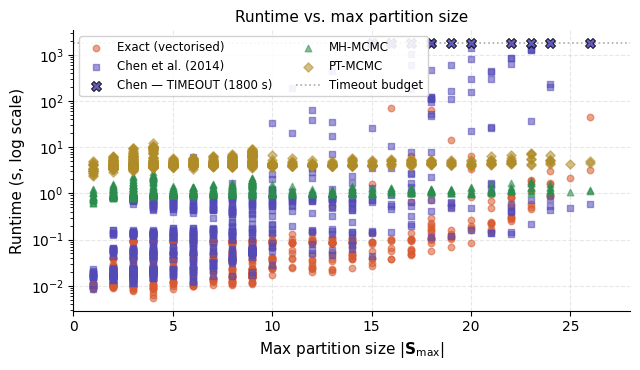

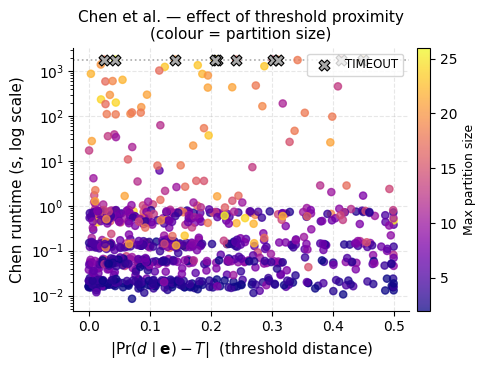

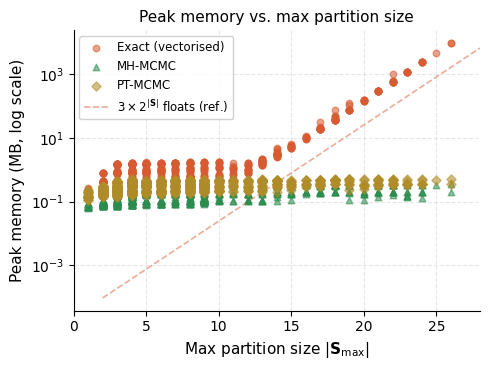

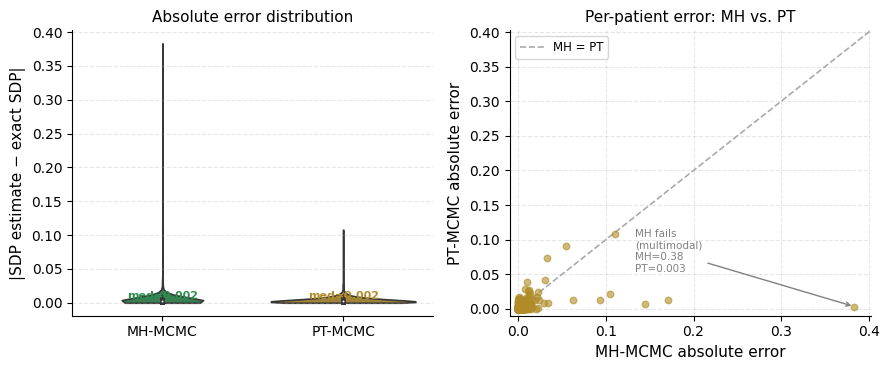

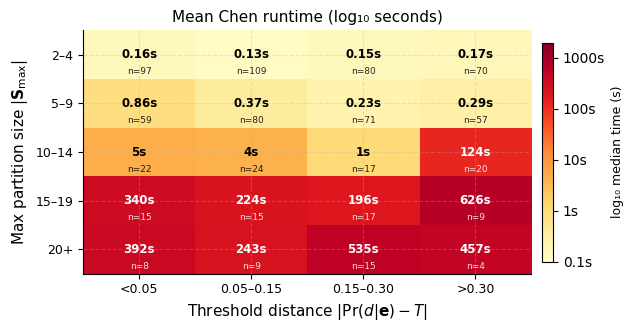

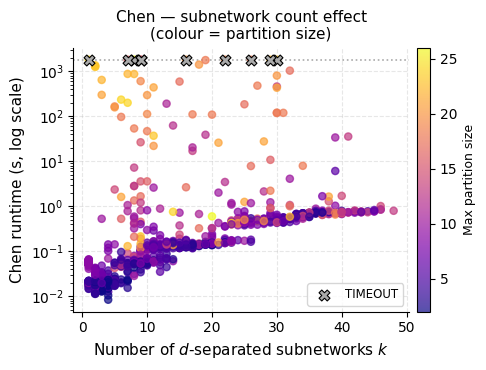

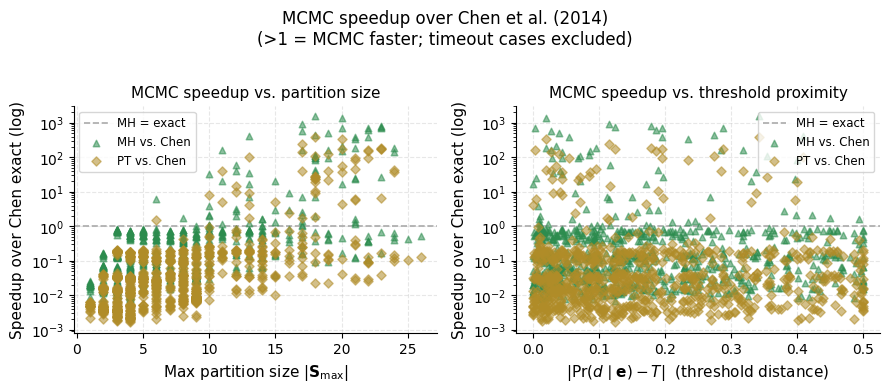


=== Summary Table ===
            Method  Median time (s)  Max time (s)  Median memory (MB)  Max memory (MB)  Failures / 177  Median abs. error  Max abs. error
Exact (vectorised)           0.0377       71.3092              0.7716        9217.6453               0                NaN             NaN
Chen et al. (2014)           0.1292     1800.0000                 NaN              NaN              10                NaN             NaN
           MH-MCMC           1.0572        2.9340              0.1684           0.3461               0             0.0023          0.3833
           PT-MCMC           4.3054       12.4497              0.3060           0.5281               0             0.0025          0.1080

All figures saved to ./figures/


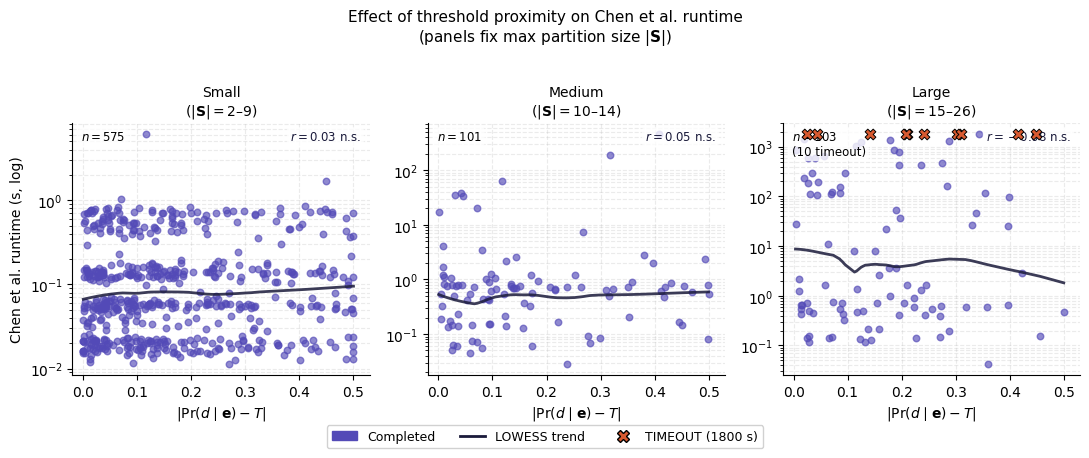

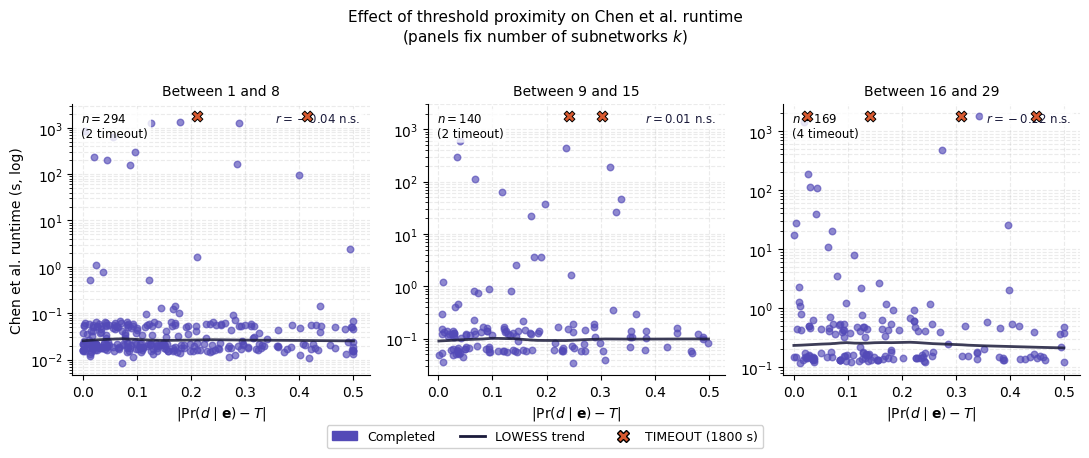

In [12]:

# ── Cell 1 ──────────────────────────────────────────────────────────────────
# Imports & global style
# ────────────────────────────────────────────────────────────────────────────

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
from matplotlib.ticker import LogLocator, NullFormatter
from scipy import stats

warnings.filterwarnings("ignore")

os.makedirs("figures", exist_ok=True)

# ── Global palette (colour-blind friendly) ──────────────────────────────────
C_VEC   = "#D85A30"   # Vectorised exact  (orange-red)
C_CHEN  = "#534AB7"   # Chen exact        (violet)
C_MH    = "#2C8C4E"   # MH-MCMC           (green)
C_PT    = "#B08C28"   # PT-MCMC           (gold)
C_LIGHT = "#AAAAAA"   # Timeout markers / annotations

METHOD_LABELS = {
    "Exact (vectorised)": C_VEC,
    "Chen et al. (2014)": C_CHEN,
    "MH-MCMC":            C_MH,
    "PT-MCMC":            C_PT,
}

FIGW = 5.0      # single-column figure width (inches)
FIGH = 3.8      # default figure height

mpl.rcParams.update({
    "font.family":     "sans-serif",
    "font.size":       10,
    "axes.labelsize":  11,
    "axes.titlesize":  11,
    "legend.fontsize": 9,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":       True,
    "grid.alpha":      0.3,
    "grid.linestyle":  "--",
})


# ── Cell 2 ──────────────────────────────────────────────────────────────────
# Load & clean data
# ────────────────────────────────────────────────────────────────────────────

df["N_Hidden"]      = (df["N_Nodes"] * df["Hidden_Ratio"]).astype(int)
df["Chen_Timeout"]  = df["Exact_SDP_Original_Status"] == "TIMEOUT"

# Fill timeout with the budget so they're visible in log plots
df["t_chen_plot"] = df["Exact_Time_sec_Original"].fillna(1800).clip(upper=1800)

# Separate the "slow but not timeout" for annotation
SLOW_THRESHOLD = 30   # seconds

print(f"Total rows          : {len(df)}")
print(f"Chen timeouts       : {df['Chen_Timeout'].sum()}")
print(f"Chen > {SLOW_THRESHOLD}s (non-TO): {((df['t_chen_plot'] > SLOW_THRESHOLD) & ~df['Chen_Timeout']).sum()}")
print(f"MH  median error    : {df['Absolute_Error'].median():.4f}")
print(f"PT  median error    : {df['PT_Absolute_Error'].median():.4f}")
print(f"Max exact memory    : {df['Exact_Peak_Memory_MB_Python'].max():.0f} MB")
print(f"Max MCMC memory     : {df['MCMC_Peak_Memory_MB_Python'].max():.2f} MB")
df.head(3)


# ── Cell 3 ──────────────────────────────────────────────────────────────────
# Figure 1 — Runtime vs max partition size (all four methods, log scale)
# ────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(FIGW * 1.3, FIGH))

alpha = 0.55
sz    = 22

# Vectorised exact
ax.scatter(df["Max_Partition_Size"], df["Exact_Time_sec"],
           c=C_VEC,  s=sz, alpha=alpha, marker="o",  zorder=3, label="Exact (vectorised)")
# Chen — timeouts as distinct marker
mask_ok = ~df["Chen_Timeout"]
ax.scatter(df.loc[mask_ok, "Max_Partition_Size"], df.loc[mask_ok, "t_chen_plot"],
           c=C_CHEN, s=sz, alpha=alpha, marker="s",  zorder=3, label="Chen et al. (2014)")
ax.scatter(df.loc[df["Chen_Timeout"], "Max_Partition_Size"],
           df.loc[df["Chen_Timeout"], "t_chen_plot"],
           c=C_CHEN, s=sz + 30, alpha=0.9, marker="X", zorder=4, edgecolors="k",
           linewidths=0.7, label="Chen — TIMEOUT (1800 s)")
# MCMC
ax.scatter(df["Max_Partition_Size"], df["MCMC_Avg_Time_sec"],
           c=C_MH,   s=sz, alpha=alpha, marker="^",  zorder=3, label="MH-MCMC")
ax.scatter(df["Max_Partition_Size"], df["PT_MCMC_Avg_Time_sec"],
           c=C_PT,   s=sz, alpha=alpha, marker="D",  zorder=3, label="PT-MCMC")

ax.set_yscale("log")
ax.set_xlabel("Max partition size $|\\mathbf{S}_{\\max}|$")
ax.set_ylabel("Runtime (s, log scale)")
ax.set_title("Runtime vs. max partition size")
ax.set_xlim(0, 28)
ax.axhline(1800, color=C_LIGHT, linestyle=":", linewidth=1.2, label="Timeout budget")
ax.legend(loc="upper left", framealpha=0.9, ncol=2, fontsize=8.5)

fig.tight_layout()
fig.savefig("figures/fig1_time_vs_mps.pdf", bbox_inches="tight")
fig.savefig("figures/fig1_time_vs_mps.png", bbox_inches="tight", dpi=150)
plt.show()


# ── Cell 4 ──────────────────────────────────────────────────────────────────
# Figure 2 — Chen runtime vs threshold distance (Figure 9 reproduction)
# ────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(FIGW, FIGH))

# colour by MPS to show the joint effect
sc = ax.scatter(
    df["Threshold_Distance"], df["t_chen_plot"],
    c=df["Max_Partition_Size"], cmap="plasma",
    s=sz + 5, alpha=0.75, zorder=3, vmin=2, vmax=26
)
ax.scatter(df.loc[df["Chen_Timeout"], "Threshold_Distance"],
           df.loc[df["Chen_Timeout"], "t_chen_plot"],
           c=C_LIGHT, s=sz + 40, marker="X", edgecolors="k",
           linewidths=0.8, zorder=5, label="TIMEOUT")

cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label("Max partition size", fontsize=9)

ax.set_yscale("log")
ax.set_xlabel("$|\\Pr(d \\mid \\mathbf{e}) - T|$  (threshold distance)")
ax.set_ylabel("Chen runtime (s, log scale)")
ax.set_title("Chen et al. — effect of threshold proximity\n(colour = partition size)")
ax.axhline(1800, color=C_LIGHT, linestyle=":", linewidth=1.2)
ax.legend(loc="upper right", fontsize=8.5)

fig.tight_layout()
fig.savefig("figures/fig2_chen_threshold_distance.pdf", bbox_inches="tight")
fig.savefig("figures/fig2_chen_threshold_distance.png", bbox_inches="tight", dpi=150)
plt.show()


# ── Cell 5 ──────────────────────────────────────────────────────────────────
# Figure 3 — Peak memory vs max partition size (exact vs MCMC)
# ────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(FIGW, FIGH))

ax.scatter(df["Max_Partition_Size"], df["Exact_Peak_Memory_MB_Python"],
           c=C_VEC,  s=sz, alpha=alpha, marker="o",  zorder=3, label="Exact (vectorised)")
ax.scatter(df["Max_Partition_Size"], df["MCMC_Peak_Memory_MB_Python"],
           c=C_MH,   s=sz, alpha=alpha, marker="^",  zorder=3, label="MH-MCMC")
ax.scatter(df["Max_Partition_Size"], df["PT_Peak_Memory_MB_Python"],
           c=C_PT,   s=sz, alpha=alpha, marker="D",  zorder=3, label="PT-MCMC")

# Annotate the 2^mps reference line
mps_range = np.linspace(2, 28, 200)
ax.plot(mps_range, (2 ** mps_range) * 8 * 3 / 1e6,
        color=C_VEC, linestyle="--", linewidth=1.2, alpha=0.5,
        label=r"$3 \times 2^{|\mathbf{S}|}$ floats (ref.)")

ax.set_yscale("log")
ax.set_xlabel("Max partition size $|\\mathbf{S}_{\\max}|$")
ax.set_ylabel("Peak memory (MB, log scale)")
ax.set_title("Peak memory vs. max partition size")
ax.set_xlim(0, 28)
ax.legend(loc="upper left", framealpha=0.9, fontsize=8.5)

fig.tight_layout()
fig.savefig("figures/fig3_memory_vs_mps.pdf", bbox_inches="tight")
fig.savefig("figures/fig3_memory_vs_mps.png", bbox_inches="tight", dpi=150)
plt.show()



# ── Cell 7 ──────────────────────────────────────────────────────────────────
# Figure 5 — Accuracy: absolute error distributions (MH vs PT)
# ────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(FIGW * 1.8, FIGH))

ax_box, ax_scatter = axes

# ── Box / violin ──
err_data = pd.DataFrame({
    "MH-MCMC": df["Absolute_Error"],
    "PT-MCMC": df["PT_Absolute_Error"],
})
err_long = err_data.melt(var_name="Method", value_name="Absolute Error")

sns.violinplot(data=err_long, x="Method", y="Absolute Error",
               palette={"MH-MCMC": C_MH, "PT-MCMC": C_PT},
               inner="box", ax=ax_box, cut=0, linewidth=1.2)
ax_box.set_title("Absolute error distribution")
ax_box.set_xlabel("")
ax_box.set_ylabel("|SDP estimate − exact SDP|")
ax_box.spines["top"].set_visible(False)
ax_box.spines["right"].set_visible(False)

# Annotate medians
for i, (method, col) in enumerate(zip(["Absolute_Error", "PT_Absolute_Error"],
                                       [C_MH, C_PT])):
    med = df[method].median()
    ax_box.text(i, med + 0.003, f"med={med:.3f}", ha="center",
                fontsize=8, color=col, fontweight="bold")

# ── Scatter: MH error vs PT error (per patient) ──
ax_scatter.scatter(df["Absolute_Error"], df["PT_Absolute_Error"],
                   c=C_PT, s=sz, alpha=0.6, zorder=3)
lim = max(df[["Absolute_Error", "PT_Absolute_Error"]].max()) * 1.05
ax_scatter.plot([0, lim], [0, lim], color=C_LIGHT, linewidth=1.2,
                linestyle="--", label="MH = PT")
ax_scatter.set_xlabel("MH-MCMC absolute error")
ax_scatter.set_ylabel("PT-MCMC absolute error")
ax_scatter.set_title("Per-patient error: MH vs. PT")
ax_scatter.set_xlim(-0.01, lim)
ax_scatter.set_ylim(-0.01, lim)
ax_scatter.legend(fontsize=8.5)
ax_scatter.spines["top"].set_visible(False)
ax_scatter.spines["right"].set_visible(False)

# Annotate the MH outlier
worst_mh = df.loc[df["Absolute_Error"].idxmax()]
ax_scatter.annotate(
    f"MH fails\n(multimodal)\nMH={worst_mh['Absolute_Error']:.2f}\nPT={worst_mh['PT_Absolute_Error']:.3f}",
    xy=(worst_mh["Absolute_Error"], worst_mh["PT_Absolute_Error"]),
    xytext=(worst_mh["Absolute_Error"] - 0.25, worst_mh["PT_Absolute_Error"] + 0.05),
    fontsize=7.5,
    arrowprops=dict(arrowstyle="->", color="grey", lw=1.0),
    color="grey",
)

fig.tight_layout()
fig.savefig("figures/fig5_mcmc_accuracy.pdf", bbox_inches="tight")
fig.savefig("figures/fig5_mcmc_accuracy.png", bbox_inches="tight", dpi=150)
plt.show()


# ── Cell 8 ──────────────────────────────────────────────────────────────────
# Figure 6 — Joint heatmap: Chen median time by (MPS bin, TD bin)
# Reproduces the spirit of Chen et al.'s Figure 9 on our data
# ────────────────────────────────────────────────────────────────────────────

mps_bins = [0, 5, 10, 15, 20, 27]
td_bins  = [0, 0.05, 0.15, 0.30, 0.50]

mps_labels = ["2–4", "5–9", "10–14", "15–19", "20+"]
td_labels  = ["<0.05", "0.05–0.15", "0.15–0.30", ">0.30"]

df["mps_bin"] = pd.cut(df["Max_Partition_Size"], bins=mps_bins, labels=mps_labels, right=True)
df["td_bin"]  = pd.cut(df["Threshold_Distance"], bins=td_bins,  labels=td_labels,  right=True)

pivot = (
    df.groupby(["mps_bin", "td_bin"], observed=True)["t_chen_plot"]
    .mean()
    .unstack("td_bin")
    .reindex(index=mps_labels, columns=td_labels)
)
count = (
    df.groupby(["mps_bin", "td_bin"], observed=True)["t_chen_plot"]
    .count()
    .unstack("td_bin")
    .reindex(index=mps_labels, columns=td_labels)
)

fig, ax = plt.subplots(figsize=(FIGW * 1.3, FIGH * 0.9))

im = ax.imshow(np.log10(pivot.values.astype(float) + 1e-3),
               cmap="YlOrRd", aspect="auto", vmin=-1, vmax=3.3)

ax.set_xticks(range(len(td_labels)))
ax.set_yticks(range(len(mps_labels)))
ax.set_xticklabels(td_labels, fontsize=9)
ax.set_yticklabels(mps_labels, fontsize=9)
ax.set_xlabel("Threshold distance $|\\Pr(d|\\mathbf{e}) - T|$")
ax.set_ylabel("Max partition size $|\\mathbf{S}_{\\max}|$")
ax.set_title("Mean Chen runtime (log₁₀ seconds)")

for i in range(len(mps_labels)):
    for j in range(len(td_labels)):
        val  = pivot.values[i, j]
        cnt  = count.values[i, j]
        if not np.isnan(val):
            txt_val = f"{val:.0f}s" if val >= 1 else f"{val:.2f}s"
            bright  = np.log10(val + 1e-3) < 1.5
            color   = "black" if bright else "white"
            ax.text(j, i, txt_val, ha="center", va="center",
                    fontsize=8.5, color=color, fontweight="bold")
            ax.text(j, i + 0.35, f"n={int(cnt)}", ha="center", va="center",
                    fontsize=6.5, color=color, alpha=0.85)

cbar = fig.colorbar(im, ax=ax, pad=0.02, shrink=0.9)
cbar.set_label("log₁₀ median time (s)", fontsize=9)
cbar.set_ticks([-1, 0, 1, 2, 3])
cbar.set_ticklabels(["0.1s", "1s", "10s", "100s", "1000s"])

fig.tight_layout()
fig.savefig("figures/fig6_chen_heatmap.pdf", bbox_inches="tight")
fig.savefig("figures/fig6_chen_heatmap.png", bbox_inches="tight", dpi=150)
plt.show()


# ── Cell 9 ──────────────────────────────────────────────────────────────────
# Figure 7 — Number of subnetworks effect (Figure 8 reproduction)
# Chen time vs Number_Subnetworks, coloured by MPS
# ────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(FIGW, FIGH))

sc = ax.scatter(
    df["Number_Subnetworks"], df["t_chen_plot"],
    c=df["Max_Partition_Size"], cmap="plasma",
    s=sz + 5, alpha=0.7, zorder=3, vmin=2, vmax=26
)
# Timeout markers
ax.scatter(df.loc[df["Chen_Timeout"], "Number_Subnetworks"],
           df.loc[df["Chen_Timeout"], "t_chen_plot"],
           c=C_LIGHT, s=sz + 40, marker="X", edgecolors="k",
           linewidths=0.8, zorder=5, label="TIMEOUT")

cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label("Max partition size", fontsize=9)

ax.set_yscale("log")
ax.set_xlabel("Number of $d$-separated subnetworks $k$")
ax.set_ylabel("Chen runtime (s, log scale)")
ax.set_title("Chen — subnetwork count effect\n(colour = partition size)")
ax.axhline(1800, color=C_LIGHT, linestyle=":", linewidth=1.2)
ax.legend(fontsize=8.5)

fig.tight_layout()
fig.savefig("figures/fig7_chen_subnetworks.pdf", bbox_inches="tight")
fig.savefig("figures/fig7_chen_subnetworks.png", bbox_inches="tight", dpi=150)
plt.show()


# ── Cell 10 ─────────────────────────────────────────────────────────────────
# Figure 8 — Summary: speedup of MCMC over exact (per patient)
# ────────────────────────────────────────────────────────────────────────────

# Speedup = exact time / MCMC avg time  (for OK exact only)
df_ok = df[~df["Chen_Timeout"]].copy()
df_ok["speedup_mh_vs_vec"]   = df_ok["Exact_Time_sec"]           / df_ok["MCMC_Avg_Time_sec"]
df_ok["speedup_mh_vs_chen"]  = df_ok["t_chen_plot"]              / df_ok["MCMC_Avg_Time_sec"]
df_ok["speedup_pt_vs_chen"]  = df_ok["t_chen_plot"]              / df_ok["PT_MCMC_Avg_Time_sec"]

fig, axes = plt.subplots(1, 2, figsize=(FIGW * 1.8, FIGH))

ax_mps, ax_td = axes

for ax in axes:
    ax.axhline(1.0, color=C_LIGHT, linestyle="--", linewidth=1.2, label="MH = exact")
    ax.set_yscale("log")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

ax_mps.scatter(df_ok["Max_Partition_Size"], df_ok["speedup_mh_vs_chen"],
               c=C_MH,  s=sz, alpha=alpha, marker="^", zorder=3, label="MH vs. Chen")
ax_mps.scatter(df_ok["Max_Partition_Size"], df_ok["speedup_pt_vs_chen"],
               c=C_PT,  s=sz, alpha=alpha, marker="D", zorder=3, label="PT vs. Chen")
ax_mps.set_xlabel("Max partition size $|\\mathbf{S}_{\\max}|$")
ax_mps.set_ylabel("Speedup over Chen exact (log)")
ax_mps.set_title("MCMC speedup vs. partition size")
ax_mps.legend(fontsize=8.5)

ax_td.scatter(df_ok["Threshold_Distance"], df_ok["speedup_mh_vs_chen"],
              c=C_MH,  s=sz, alpha=alpha, marker="^", zorder=3, label="MH vs. Chen")
ax_td.scatter(df_ok["Threshold_Distance"], df_ok["speedup_pt_vs_chen"],
              c=C_PT,  s=sz, alpha=alpha, marker="D", zorder=3, label="PT vs. Chen")
ax_td.set_xlabel("$|\\Pr(d \\mid \\mathbf{e}) - T|$  (threshold distance)")
ax_td.set_ylabel("Speedup over Chen exact (log)")
ax_td.set_title("MCMC speedup vs. threshold proximity")
ax_td.legend(fontsize=8.5)

fig.suptitle("MCMC speedup over Chen et al. (2014)\n(>1 = MCMC faster; timeout cases excluded)", y=1.02)
fig.tight_layout()
fig.savefig("figures/fig8_speedup.pdf", bbox_inches="tight")
fig.savefig("figures/fig8_speedup.png", bbox_inches="tight", dpi=150)
plt.show()


# ── Cell 11 ─────────────────────────────────────────────────────────────────
# Summary table (print + return as DataFrame)
# ────────────────────────────────────────────────────────────────────────────

summary = pd.DataFrame({
    "Method": ["Exact (vectorised)", "Chen et al. (2014)", "MH-MCMC", "PT-MCMC"],
    "Median time (s)": [
        df["Exact_Time_sec"].median(),
        df["t_chen_plot"].median(),
        df["MCMC_Avg_Time_sec"].median(),
        df["PT_MCMC_Avg_Time_sec"].median(),
    ],
    "Max time (s)": [
        df["Exact_Time_sec"].max(),
        df["t_chen_plot"].max(),
        df["MCMC_Avg_Time_sec"].max(),
        df["PT_MCMC_Avg_Time_sec"].max(),
    ],
    "Median memory (MB)": [
        df["Exact_Peak_Memory_MB_Python"].median(),
        float("nan"),
        df["MCMC_Peak_Memory_MB_Python"].median(),
        df["PT_Peak_Memory_MB_Python"].median(),
    ],
    "Max memory (MB)": [
        df["Exact_Peak_Memory_MB_Python"].max(),
        float("nan"),
        df["MCMC_Peak_Memory_MB_Python"].max(),
        df["PT_Peak_Memory_MB_Python"].max(),
    ],
    "Failures / 177": [
        0,
        df["Chen_Timeout"].sum(),
        0,
        0,
    ],
    "Median abs. error": [
        float("nan"),
        float("nan"),
        df["Absolute_Error"].median(),
        df["PT_Absolute_Error"].median(),
    ],
    "Max abs. error": [
        float("nan"),
        float("nan"),
        df["Absolute_Error"].max(),
        df["PT_Absolute_Error"].max(),
    ],
})

print("\n=== Summary Table ===")
print(summary.to_string(index=False, float_format="{:.4f}".format))

print("\nAll figures saved to ./figures/")
summary


# ── Cell 12 ─────────────────────────────────────────────────────────────────
# Figure 9 — Threshold-distance effect, controlling for partition size
# Three panels fix MPS in small/medium/large bands so the TD effect
# can be read cleanly without the partition-size confound.
# ────────────────────────────────────────────────────────────────────────────

from statsmodels.nonparametric.smoothers_lowess import lowess

BINS_TD = [
    (2,  10, "Small\n($|\\mathbf{S}|=2$–$9$)"),
    (10, 15, "Medium\n($|\\mathbf{S}|=10$–$14$)"),
    (15, 27, "Large\n($|\\mathbf{S}|=15$–$26$)"),
]
C_DOT    = "#534AB7"
C_TO_DOT = "#D85A30"
C_TREND  = "#1A1A3A"

fig, axes = plt.subplots(1, 3, figsize=(11, 4.2), sharey=False)
fig.subplots_adjust(wspace=0.38)

for ax, (lo, hi, title) in zip(axes, BINS_TD):
    sub     = df[(df["Max_Partition_Size"] >= lo) & (df["Max_Partition_Size"] < hi)].copy()
    ok      = sub[~sub["Chen_Timeout"]]
    timeout = sub[sub["Chen_Timeout"]]

    ax.scatter(ok["Threshold_Distance"], ok["t_chen_plot"],
               c=C_DOT, s=22, alpha=0.65, zorder=3)
    if len(timeout):
        ax.scatter(timeout["Threshold_Distance"], timeout["t_chen_plot"],
                   c=C_TO_DOT, s=60, marker="X", edgecolors="k",
                   linewidths=0.7, zorder=5)

    ax.set_yscale("log")
    ax.set_xlabel("$|\\Pr(d\\mid\\mathbf{e})-T|$", fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, which="both", alpha=0.25, linestyle="--")

    # LOWESS on log10(time)
    if len(ok) >= 6:
        x_ok = ok["Threshold_Distance"].values
        y_ok = np.log10(ok["t_chen_plot"].values)
        order = np.argsort(x_ok)
        sm = lowess(y_ok[order], x_ok[order], frac=0.55, return_sorted=True)
        ax.plot(sm[:, 0], 10 ** sm[:, 1],
                color=C_TREND, linewidth=2.0, zorder=4, alpha=0.85)

    # Pearson r annotation
    if len(ok) >= 6:
        r, p = stats.pearsonr(ok["Threshold_Distance"], np.log10(ok["t_chen_plot"]))
        sig  = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "n.s."))
        ax.text(0.97, 0.97, f"$r={r:.2f}$ {sig}",
                ha="right", va="top", transform=ax.transAxes,
                fontsize=8.5, color=C_TREND,
                bbox=dict(boxstyle="round,pad=0.25", fc="white", alpha=0.8, ec="none"))

    n_ok = len(ok); n_to = len(timeout)
    note = f"$n={n_ok + n_to}$" + (f"\n({n_to} timeout)" if n_to else "")
    ax.text(0.03, 0.97, note, ha="left", va="top", transform=ax.transAxes,
            fontsize=8.5,
            bbox=dict(boxstyle="round,pad=0.25", fc="white", alpha=0.8, ec="none"))
    ax.set_xlim(-0.02, 0.53)

axes[0].set_ylabel("Chen et al. runtime (s, log)", fontsize=10)

handles_td = [
    mpatches.Patch(color=C_DOT,    label="Completed"),
    plt.Line2D([0], [0], color=C_TREND, linewidth=2, label="LOWESS trend"),
    plt.Line2D([0], [0], marker="X", color="w", markerfacecolor=C_TO_DOT,
               markersize=9, markeredgecolor="k", label="TIMEOUT (1800 s)"),
]
fig.legend(handles=handles_td, loc="lower center", ncol=3,
           fontsize=9, bbox_to_anchor=(0.5, -0.04), framealpha=0.9)
fig.suptitle("Effect of threshold proximity on Chen et al. runtime\n"
             "(panels fix max partition size $|\\mathbf{S}|$)", y=1.02, fontsize=11)

fig.tight_layout()
fig.savefig("figures/fig9_td_effect_fixed_mps.pdf", bbox_inches="tight")
fig.savefig("figures/fig9_td_effect_fixed_mps.png", bbox_inches="tight", dpi=150)
plt.show()

# ── Cell 13 ─────────────────────────────────────────────────────────────────
# Figure 10 - Threshold-distance effect, controlling for subnetwork count
# Similar to Figure 9 but fixing the number of subnetworks k instead of MPS.

BINS_K = [
    (1, 8, "Between 1 and 8"),
    (9, 15, "Between 9 and 15"),
    (16, 30, "Between 16 and 29"),
]

fig, axes = plt.subplots(1, 3, figsize=(11, 4.2), sharey=False)
fig.subplots_adjust(wspace=0.38)    

for ax, (lo, hi, title) in zip(axes, BINS_K):
    sub     = df[(df["Number_Subnetworks"] >= lo) & (df["Number_Subnetworks"] < hi)].copy()
    ok      = sub[~sub["Chen_Timeout"]]
    timeout = sub[sub["Chen_Timeout"]]

    ax.scatter(ok["Threshold_Distance"], ok["t_chen_plot"],
               c=C_DOT, s=22, alpha=0.65, zorder=3)
    if len(timeout):
        ax.scatter(timeout["Threshold_Distance"], timeout["t_chen_plot"],
                   c=C_TO_DOT, s=60, marker="X", edgecolors="k",
                   linewidths=0.7, zorder=5)

    ax.set_yscale("log")
    ax.set_xlabel("$|\\Pr(d\\mid\\mathbf{e})-T|$", fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, which="both", alpha=0.25, linestyle="--")

    # LOWESS on log10(time)
    if len(ok) >= 6:
        x_ok = ok["Threshold_Distance"].values
        y_ok = np.log10(ok["t_chen_plot"].values)
        order = np.argsort(x_ok)
        sm = lowess(y_ok[order], x_ok[order], frac=0.55, return_sorted=True)
        ax.plot(sm[:, 0], 10 ** sm[:, 1],
                color=C_TREND, linewidth=2.0, zorder=4, alpha=0.85)

    # Pearson r annotation
    if len(ok) >= 6:
        r, p = stats.pearsonr(ok["Threshold_Distance"], np.log10(ok["t_chen_plot"]))
        sig  = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "n.s."))
        ax.text(0.97, 0.97, f"$r={r:.2f}$ {sig}",
                ha="right", va="top", transform=ax.transAxes,
                fontsize=8.5, color=C_TREND,
                bbox=dict(boxstyle="round,pad=0.25", fc="white", alpha=0.8, ec="none"))
    n_ok = len(ok); n_to = len(timeout)
    note = f"$n={n_ok + n_to}$" + (f"\n({n_to} timeout)" if n_to else "")
    ax.text(0.03, 0.97, note, ha="left", va="top", transform=ax.transAxes,  
            fontsize=8.5,
            bbox=dict(boxstyle="round,pad=0.25", fc="white", alpha=0.8, ec="none"))
    ax.set_xlim(-0.02, 0.53)

axes[0].set_ylabel("Chen et al. runtime (s, log)", fontsize=10) 
handles_k = [
    mpatches.Patch(color=C_DOT,    label="Completed"),
    plt.Line2D([0], [0], color=C_TREND, linewidth=2, label="LOWESS trend"),
    plt.Line2D([0], [0], marker="X", color="w", markerfacecolor=C_TO_DOT,
               markersize=9, markeredgecolor="k", label="TIMEOUT (1800 s)"),
]
fig.legend(handles=handles_k, loc="lower center", ncol=3,
              fontsize=9, bbox_to_anchor=(0.5, -0.04), framealpha=0.9)
fig.suptitle("Effect of threshold proximity on Chen et al. runtime\n"
             "(panels fix number of subnetworks $k$)", y=1.02, fontsize=11)
fig.tight_layout()
fig.savefig("figures/fig10_td_effect_fixed_k.pdf", bbox_inches="tight")
fig.savefig("figures/fig10_td_effect_fixed_k.png", bbox_inches="tight", dpi=150)
plt.show()

In [16]:
df.columns

Index(['Network', 'N_Nodes', 'Density', 'Rigidity', 'Hidden_Ratio',
       'Target_Bucket', 'Target_Node', 'Target_Value', 'Number_Subnetworks',
       'Max_Partition_Size', 'Max_Tensor_Size', 'Threshold_Distance',
       'Exact_SDP', 'Exact_Time_sec', 'Exact_Peak_Memory_MB_Python',
       'Exact_Peak_Memory_MB_RSS', 'Exact_SDP_Original',
       'Exact_Time_sec_Original', 'Exact_Peak_Memory_MB_Python_Original',
       'Exact_Peak_Memory_MB_RSS_Original', 'Exact_SDP_Original_Status',
       'MCMC_Mean_SDP', 'MCMC_Variance', 'MCMC_Avg_Time_sec',
       'MCMC_Peak_Memory_MB_Python', 'MCMC_Peak_Memory_MB_RSS',
       'Absolute_Error', 'PT_MCMC_Mean_SDP', 'PT_MCMC_Variance',
       'PT_MCMC_Avg_Time_sec', 'PT_Peak_Memory_MB_Python',
       'PT_Peak_Memory_MB_RSS', 'PT_Absolute_Error'],
      dtype='object')

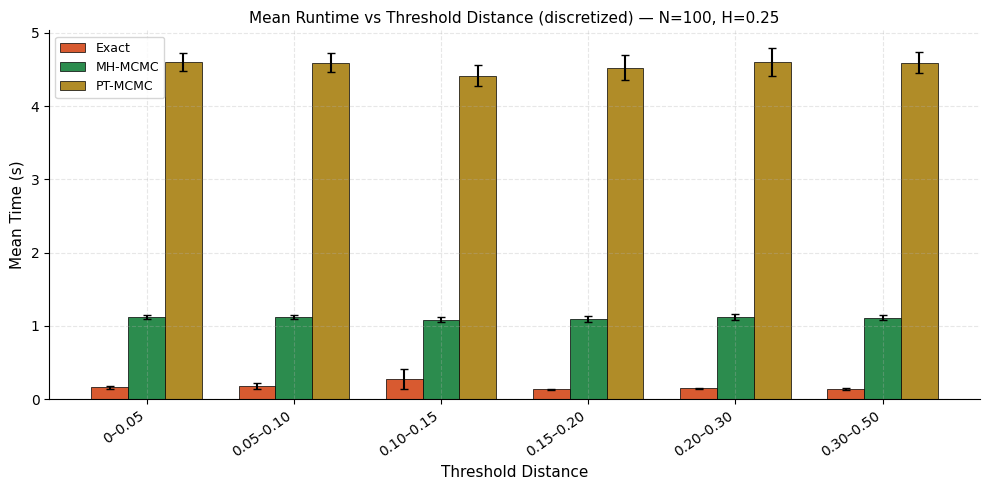

In [23]:
# Time versus threshold distance (discretized) — only N_Nodes==100 and Hidden_Ratio==0.25
sub = df[(df['N_Nodes'] == 100) & (df['Hidden_Ratio'] == 0.25)].copy()

fig, ax = plt.subplots(figsize=(10, 5))

# Discretize threshold distance into bins
td_bins_plot = [0, 0.05, 0.10, 0.15, 0.20, 0.30, 0.50]
td_labels_plot = ['0–0.05', '0.05–0.10', '0.10–0.15', '0.15–0.20', '0.20–0.30', '0.30–0.50']
sub['td_discrete'] = pd.cut(sub['Threshold_Distance'], bins=td_bins_plot, labels=td_labels_plot, right=True)

# Calculate mean time per bin for each method
td_summary = sub.groupby('td_discrete', observed=True).agg(
    exact_mean=('Exact_Time_sec_Original', 'mean'),
    exact_sem=('Exact_Time_sec_Original', 'sem'),
    mcmc_mean=('MCMC_Avg_Time_sec', 'mean'),
    mcmc_sem=('MCMC_Avg_Time_sec', 'sem'),
    pt_mean=('PT_MCMC_Avg_Time_sec', 'mean'),
    pt_sem=('PT_MCMC_Avg_Time_sec', 'sem'),
).reindex(td_labels_plot)

x_pos_td = np.arange(len(td_summary))
width = 0.25

ax.bar(x_pos_td - width, td_summary['exact_mean'].fillna(0), width, yerr=td_summary['exact_sem'].fillna(0),
       capsize=3, color=C_VEC, label='Exact', edgecolor='black', linewidth=0.5)
ax.bar(x_pos_td, td_summary['mcmc_mean'].fillna(0), width, yerr=td_summary['mcmc_sem'].fillna(0),
       capsize=3, color=C_MH, label='MH-MCMC', edgecolor='black', linewidth=0.5)
ax.bar(x_pos_td + width, td_summary['pt_mean'].fillna(0), width, yerr=td_summary['pt_sem'].fillna(0),
       capsize=3, color=C_PT, label='PT-MCMC', edgecolor='black', linewidth=0.5)

ax.set_xticks(x_pos_td)
ax.set_xticklabels(td_labels_plot, rotation=35, ha='right')
ax.set_xlabel('Threshold Distance')
ax.set_ylabel('Mean Time (s)')
ax.set_title('Mean Runtime vs Threshold Distance (discretized) — N=100, H=0.25')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

fig.tight_layout()
fig.savefig('time_vs_threshold_distance_discretized_n100_h025.png', dpi=300, bbox_inches='tight')
plt.show()